# Name: Royan Dsouza
## Roll no.:21
## Expt.-8: Clustering of Countries with World Bank API
# Machine Learning Lab

In [1]:
!pip install requests

  Using cached requests-2.32.5-py3-none-any.whl (64 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)
  Using cached idna-3.11-py3-none-any.whl (71 kB)


You should consider upgrading via the 'c:\users\hp\ml-anish\scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

## Collecting Data From API

In [14]:
def fetch_indicator(code, year=2022):
    url=f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]

    data={}
    for item in response:
        country = item["country"]["value"]
        value = item["value"]
        if value is not None:
            data[country] = value
    return pd.Series(data, name=code)
        

In [15]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [16]:
df = pd.concat([gdp, pop, life, lit], axis=1)

In [23]:
# Define new column name
df.columns = ["GDP", "Population", "LifeExpectancy", "LiteracyRate"]

# Remove missing data
df.dropna(inplace=True)

df.head()


,GDP,Population,LifeExpectancy,LiteracyRate
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [24]:
df.tail()

,GDP,Population,LifeExpectancy,LiteracyRate
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


In [25]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

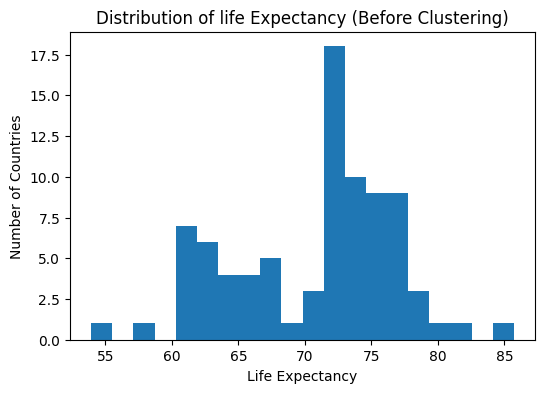

In [26]:
plt.figure(figsize=(6,4))
plt.hist(df["LifeExpectancy"], bins=20)
plt.xlabel("Life Expectancy")
plt.ylabel("Number of Countries")
plt.title("Distribution of life Expectancy (Before Clustering)")
plt.show()

k	WCSS
1 	 336.0
2 	 206.43717192603816
3 	 142.06028324967593
4 	 122.4640064142117
5 	 68.71234707726032
6 	 56.092718405819134
7 	 51.08265517326419
8 	 41.70851027024397
9 	 31.213863029560216
10 	 27.047250986507716




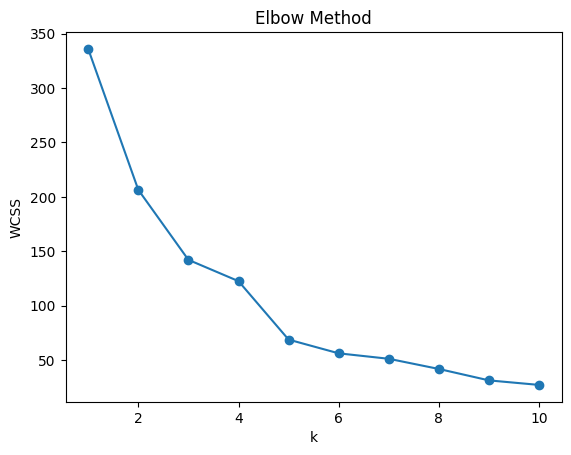

In [28]:
wcss = []
for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

print("k\tWCSS")
for i in range(10):
    print(i+1,"\t", wcss[i])

print("\n")

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("k")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## Part 3: Clustering

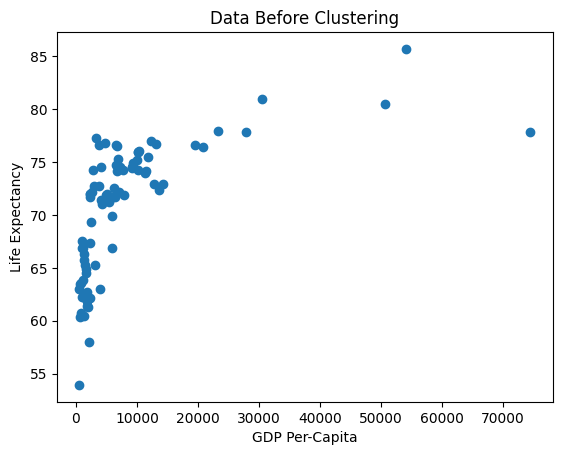

In [30]:
plt.scatter(df["GDP"], df["LifeExpectancy"])
plt.xlabel("GDP Per-Capita")
plt.ylabel("Life Expectancy")
plt.title("Data Before Clustering")
plt.show()

In [32]:
kmeans = KMeans(n_clusters=3, random_state=0)

# Label the clusters means give numbers to them and add it as column KMeanClustering
labels_km = kmeans.fit_predict(X_scaled)
df["KMeansCluster"] = labels_km

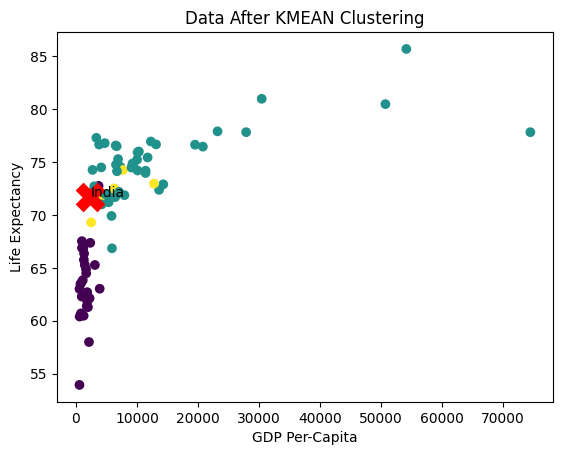

In [55]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_km)
plt.xlabel("GDP Per-Capita")
plt.ylabel("Life Expectancy")
plt.title("Data After KMEAN Clustering")

india = df.loc["India"]
plt.scatter(india["GDP"], india["LifeExpectancy"], s=400, color='Red', marker='X')
plt.text(india["GDP"], india["LifeExpectancy"], "India")

plt.show()

In [36]:
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(X_scaled)
df["HierarchicalCluster"] = labels_hc

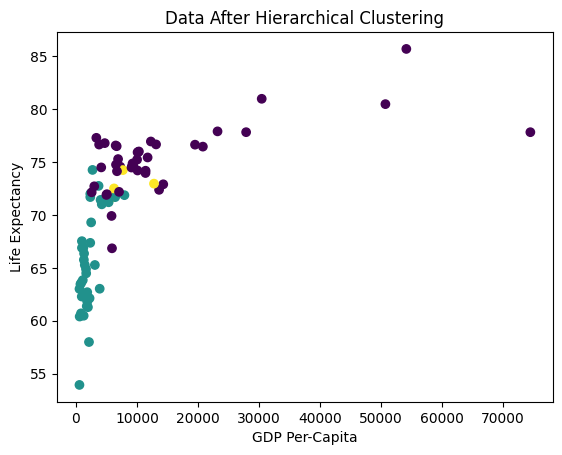

In [37]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_hc)
plt.xlabel("GDP Per-Capita")
plt.ylabel("Life Expectancy")
plt.title("Data After Hierarchical Clustering")
plt.show()

In [38]:
linked = linkage(X_scaled, method = "ward")


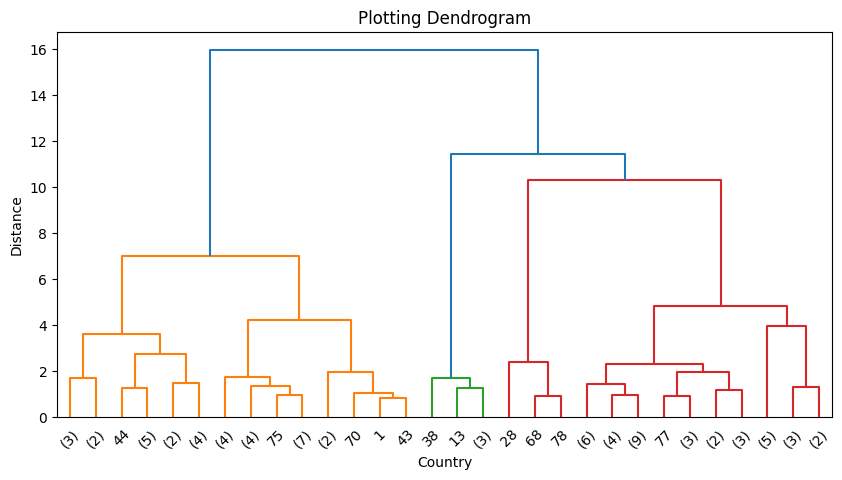

In [39]:
plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title("Plotting Dendrogram")
plt.xlabel("Country")
plt.ylabel("Distance")
plt.show()

In [44]:
def data(country_name):
    result = df.loc[country_name]

    print("Country:", country_name)
    print("GDP per capita:", result["GDP"])
    print("Population:", result["Population"])
    print("Life Expectancy:", result["LifeExpectancy"])
    print("Literacy Rate:", result["LiteracyRate"])
    print("KMeans Cluster:", result["KMeansCluster"])
    print("Hierarchichal Cluster:", result["HierarchicalCluster"])

In [45]:
data("India")

Country: India
GDP per capita: 2347.44829434623
Population: 1425423212.0
Life Expectancy: 71.698
Literacy Rate: 76.3199996948242
KMeans Cluster: 1.0
Hierarchichal Cluster: 1.0


In [46]:
data("North America")

Country: North America
GDP per capita: 74535.6365392629
Population: 373018004.0
Life Expectancy: 77.8327679594239
Literacy Rate: 98.7891464233398
KMeans Cluster: 1.0
Hierarchichal Cluster: 0.0


In [47]:
data("Brazil")

Country: Brazil
GDP per capita: 9281.33282136864
Population: 210306415.0
Life Expectancy: 74.872
Literacy Rate: 94.3853874531348
KMeans Cluster: 1.0
Hierarchichal Cluster: 0.0


In [50]:
data("Viet Nam")

Country: Viet Nam
GDP per capita: 4147.69777213621
Population: 99680655.0
Life Expectancy: 74.502
Literacy Rate: 96.129997253418
KMeans Cluster: 1.0
Hierarchichal Cluster: 0.0


In [51]:
data("Bahrain")

Country: Bahrain
GDP per capita: 30470.5219276023
Population: 1524693.0
Life Expectancy: 80.992
Literacy Rate: 97.870002746582
KMeans Cluster: 1.0
Hierarchichal Cluster: 0.0


In [52]:
cluster_summary = df.groupby("KMeansCluster")[["GDP", "Population", "LifeExpectancy", "LiteracyRate"]].mean()
print(cluster_summary)

                        GDP    Population  LifeExpectancy  LiteracyRate
KMeansCluster                                                          
0               1601.971896  4.854521e+08       63.478867     66.779721
1              12288.225626  4.669122e+08       74.753258     92.910908
2               6437.349751  5.501554e+09       71.975830     84.851687
